# CSCI-544 NLP Final project
# Group36: Jeslyn Yang, Wenwen Han, Ivan Loh, Rachel Lin, Neil Bai
# Detection of AI Generated Text-Blstm_CNN Model

In [34]:
import os
import re
import gc
import math
import time
import json
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, confusion_matrix, classification_report
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


## Config

In [35]:

CFG = {
    "csv_path": "/content/Training_Essay_Data.csv",
    "text_col": "text",
    "label_col": "generated",

    "drop_duplicates": True,
    "min_words": 40,
    "sample_per_class": 4000,
    "test_size": 0.15,
    "val_size": 0.15,

    "vocab_size": 50000,
    "max_len": 384,
    "min_freq": 2,

    "embed_dim": 256,
    "lstm_hidden": 128,
    "lstm_layers": 2,
    "kernel_sizes": [3, 5, 7],
    "num_filters": 128,
    "fc_hidden": 128,
    "dropout": 0.4,
    "emb_dropout": 0.15,

    "batch_size": 64 if torch.cuda.is_available() else 16,
    "epochs": 8,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "grad_clip": 1.0,
    "patience": 2,
    "num_workers": 2 if torch.cuda.is_available() else 0,
    "use_amp": torch.cuda.is_available(),

    "save_dir": "/content/blstm_cnn_outputs"
}
os.makedirs(CFG["save_dir"], exist_ok=True)
print(json.dumps(CFG, indent=2))


{
  "csv_path": "/content/Training_Essay_Data.csv",
  "text_col": "text",
  "label_col": "generated",
  "drop_duplicates": true,
  "min_words": 40,
  "sample_per_class": 4000,
  "test_size": 0.15,
  "val_size": 0.15,
  "vocab_size": 50000,
  "max_len": 384,
  "min_freq": 2,
  "embed_dim": 256,
  "lstm_hidden": 128,
  "lstm_layers": 2,
  "kernel_sizes": [
    3,
    5,
    7
  ],
  "num_filters": 128,
  "fc_hidden": 128,
  "dropout": 0.4,
  "emb_dropout": 0.15,
  "batch_size": 64,
  "epochs": 8,
  "lr": 0.001,
  "weight_decay": 0.0001,
  "grad_clip": 1.0,
  "patience": 2,
  "num_workers": 2,
  "use_amp": true,
  "save_dir": "/content/blstm_cnn_outputs"
}


## Load dataset

In [36]:
assert os.path.exists(CFG["csv_path"]), f"CSV not found: {CFG['csv_path']}"

df = pd.read_csv(CFG["csv_path"])
print("Original shape:", df.shape)
print(df.head())

required = {CFG["text_col"], CFG["label_col"]}
missing = required - set(df.columns)
assert not missing, f"Missing required columns: {missing}"

df = df[[CFG["text_col"], CFG["label_col"]]].copy()
df.columns = ["text", "label"]

df["text"] = df["text"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
df = df[df["text"].str.len() > 0]
df["label"] = df["label"].astype(int)

df["word_count"] = df["text"].str.split().apply(len)
df = df[df["word_count"] >= CFG["min_words"]].copy()

if CFG["drop_duplicates"]:
    before = len(df)
    df = df.drop_duplicates(subset=["text"]).copy()
    print(f"Dropped duplicates: {before - len(df)}")

print("After cleaning:", df.shape)
print(df["label"].value_counts(dropna=False))
print(df["word_count"].describe())

parts = []
for label, group in df.groupby("label"):
    if CFG["sample_per_class"] is None:
        sampled = group.sample(frac=1.0, random_state=SEED)
    else:
        n = min(CFG["sample_per_class"], len(group))
        sampled = group.sample(n=n, random_state=SEED)
    parts.append(sampled)

df_bal = pd.concat(parts, axis=0).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
print("Balanced working shape:", df_bal.shape)
print(df_bal["label"].value_counts())

train_df, temp_df = train_test_split(
    df_bal,
    test_size=CFG["val_size"] + CFG["test_size"],
    random_state=SEED,
    stratify=df_bal["label"]
)

relative_test = CFG["test_size"] / (CFG["val_size"] + CFG["test_size"])
val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test,
    random_state=SEED,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape, train_df["label"].value_counts().to_dict())
print("Val  :", val_df.shape, val_df["label"].value_counts().to_dict())
print("Test :", test_df.shape, test_df["label"].value_counts().to_dict())

train_df.to_csv(os.path.join(CFG["save_dir"], "train_split.csv"), index=False)
val_df.to_csv(os.path.join(CFG["save_dir"], "val_split.csv"), index=False)
test_df.to_csv(os.path.join(CFG["save_dir"], "test_split.csv"), index=False)

for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    lengths = split_df["text"].str.split().apply(len)
    print(
        f"{name}: mean={lengths.mean():.1f}, median={lengths.median():.1f}, "
        f"p90={lengths.quantile(0.90):.1f}, max={lengths.max()}"
    )


Original shape: (29145, 2)
                                                text  generated
0  Car-free cities have become a subject of incre...          1
1  Car Free Cities  Car-free cities, a concept ga...          1
2    A Sustainable Urban Future  Car-free cities ...          1
3    Pioneering Sustainable Urban Living  In an e...          1
4    The Path to Sustainable Urban Living  In an ...          1
Dropped duplicates: 1861
After cleaning: (27278, 3)
label
0    16098
1    11180
Name: count, dtype: int64
count    27278.000000
mean       373.220214
std        168.717735
min         48.000000
25%        255.000000
50%        345.000000
75%        459.000000
max       1650.000000
Name: word_count, dtype: float64
Balanced working shape: (8000, 3)
label
0    4000
1    4000
Name: count, dtype: int64
Train: (5600, 3) {1: 2800, 0: 2800}
Val  : (1200, 3) {1: 600, 0: 600}
Test : (1200, 3) {1: 600, 0: 600}
train: mean=361.6, median=342.0, p90=573.1, max=1367
val: mean=358.8, median=340.0, 

## Tokenization

In [37]:
TOKEN_RE = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?|\d+|[^\w\s]")

def tokenize(text):
    return TOKEN_RE.findall(text.lower())

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

counter = Counter()
for text in train_df["text"]:
    counter.update(tokenize(text))

itos = [PAD_TOKEN, UNK_TOKEN]
for tok, freq in counter.most_common():
    if freq < CFG["min_freq"]:
        break
    itos.append(tok)
    if len(itos) >= CFG["vocab_size"]:
        break

stoi = {tok: i for i, tok in enumerate(itos)}
PAD_IDX = stoi[PAD_TOKEN]
UNK_IDX = stoi[UNK_TOKEN]

print("Vocab size:", len(itos))
print("Top tokens:", itos[2:22])

with open(os.path.join(CFG["save_dir"], "vocab.json"), "w", encoding="utf-8") as f:
    json.dump({"itos": itos}, f)


Vocab size: 16781
Top tokens: ['.', 'the', ',', 'to', 'and', 'a', 'of', 'in', 'is', 'that', 'it', 'for', 'you', 'be', 'are', 'can', 'they', 'on', 'this', 'have']


In [38]:
class EssayDataset(Dataset):
    def __init__(self, df, stoi, max_len):
        self.texts = df["text"].tolist()
        self.labels = df["label"].astype(int).tolist()
        self.stoi = stoi
        self.max_len = max_len

    def encode(self, text):
        ids = [self.stoi.get(tok, UNK_IDX) for tok in tokenize(text)]
        if len(ids) == 0:
            ids = [UNK_IDX]
        return ids[:self.max_len]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = self.encode(self.texts[idx])
        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
            "length": len(ids)
        }

def collate_batch(batch):
    lengths = [item["length"] for item in batch]
    max_batch_len = max(lengths)
    padded = torch.full((len(batch), max_batch_len), PAD_IDX, dtype=torch.long)
    labels = torch.tensor([item["label"] for item in batch], dtype=torch.long)

    for i, item in enumerate(batch):
        seq = item["input_ids"]
        padded[i, : len(seq)] = seq

    return {
        "input_ids": padded,
        "labels": labels,
        "lengths": torch.tensor(lengths, dtype=torch.long)
    }

train_ds = EssayDataset(train_df, stoi, CFG["max_len"])
val_ds = EssayDataset(val_df, stoi, CFG["max_len"])
test_ds = EssayDataset(test_df, stoi, CFG["max_len"])

train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_batch
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_batch
)

test_loader = DataLoader(
    test_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_batch
)

batch = next(iter(train_loader))
print(batch["input_ids"].shape, batch["labels"].shape)


torch.Size([64, 384]) torch.Size([64])


## Model

In [39]:
class SpatialDropout(nn.Module):
    def __init__(self, p=0.1):
        super().__init__()
        self.dropout = nn.Dropout2d(p)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.dropout(x)
        x = x.transpose(1, 2)
        return x

class BLSTMCNN(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        lstm_hidden,
        lstm_layers,
        kernel_sizes,
        num_filters,
        fc_hidden,
        dropout,
        emb_dropout,
        pad_idx
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.emb_dropout = SpatialDropout(emb_dropout)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            dropout=dropout if lstm_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=True
        )

        conv_in = lstm_hidden * 2
        self.convs = nn.ModuleList([
            nn.Conv1d(conv_in, num_filters, kernel_size=k, padding=k // 2)
            for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(num_filters * len(kernel_sizes), fc_hidden)
        self.fc2 = nn.Linear(fc_hidden, 2)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        x = self.emb_dropout(x)

        lstm_out, _ = self.lstm(x)
        conv_in = lstm_out.transpose(1, 2)

        pooled = []
        for conv in self.convs:
            h = F.relu(conv(conv_in))
            p = F.max_pool1d(h, kernel_size=h.size(2)).squeeze(2)
            pooled.append(p)

        x = torch.cat(pooled, dim=1)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        logits = self.fc2(x)
        return logits

model = BLSTMCNN(
    vocab_size=len(itos),
    embed_dim=CFG["embed_dim"],
    lstm_hidden=CFG["lstm_hidden"],
    lstm_layers=CFG["lstm_layers"],
    kernel_sizes=CFG["kernel_sizes"],
    num_filters=CFG["num_filters"],
    fc_hidden=CFG["fc_hidden"],
    dropout=CFG["dropout"],
    emb_dropout=CFG["emb_dropout"],
    pad_idx=PAD_IDX
).to(DEVICE)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"Trainable params: {num_params:,}")


BLSTMCNN(
  (embedding): Embedding(16781, 256, padding_idx=0)
  (emb_dropout): SpatialDropout(
    (dropout): Dropout2d(p=0.15, inplace=False)
  )
  (lstm): LSTM(256, 128, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (convs): ModuleList(
    (0): Conv1d(256, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): Conv1d(256, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (2): Conv1d(256, 128, kernel_size=(7,), stride=(1,), padding=(3,))
  )
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)
Trainable params: 5,627,906


##Training

In [40]:

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"]
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=1
)
scaler = GradScaler(enabled=CFG["use_amp"])

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    epoch_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        labels = batch["labels"].to(DEVICE, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with autocast(enabled=CFG["use_amp"]):
                logits = model(input_ids)
                loss = criterion(logits, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
                scaler.step(optimizer)
                scaler.update()

        probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
        labs = labels.detach().cpu().numpy()

        epoch_loss += loss.item() * input_ids.size(0)
        all_labels.extend(labs.tolist())
        all_preds.extend(preds.tolist())
        all_probs.extend(probs.tolist())

    avg_loss = epoch_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="binary", zero_division=0
    )
    auc = roc_auc_score(all_labels, all_probs)

    metrics = {
        "loss": avg_loss,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc
    }
    return metrics, np.array(all_labels), np.array(all_preds), np.array(all_probs)

history = []
best_val_f1 = -1.0
best_path = os.path.join(CFG["save_dir"], "best_blstm_cnn.pt")
patience_counter = 0

for epoch in range(1, CFG["epochs"] + 1):
    start = time.time()

    train_metrics, _, _, _ = run_epoch(model, train_loader, optimizer=optimizer)
    val_metrics, _, _, _ = run_epoch(model, val_loader, optimizer=None)

    scheduler.step(val_metrics["f1"])

    row = {
        "epoch": epoch,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()},
        "lr": optimizer.param_groups[0]["lr"],
        "minutes": (time.time() - start) / 60.0
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_metrics['loss']:.4f} train_f1={train_metrics['f1']:.4f} train_auc={train_metrics['auc']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} val_f1={val_metrics['f1']:.4f} val_auc={val_metrics['auc']:.4f} | "
        f"lr={optimizer.param_groups[0]['lr']:.2e}"
    )

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        patience_counter = 0
        torch.save(model.state_dict(), best_path)
        print("  -> saved new best model")
    else:
        patience_counter += 1
        print(f"  -> no improvement ({patience_counter}/{CFG['patience']})")

    if patience_counter >= CFG["patience"]:
        print("Early stopping triggered.")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(CFG["save_dir"], "training_history.csv"), index=False)
history_df


/tmp/ipykernel_3128/3751717104.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=CFG["use_amp"])
/tmp/ipykernel_3128/3751717104.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG["use_amp"]):
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  return F.dropout2d(input, self.p, self.training, self.inplace)


Epoch 01 | train_loss=0.3727 train_f1=0.8119 train_auc=0.9133 | val_loss=0.1750 val_f1=0.9327 val_auc=0.9883 | lr=1.00e-03
  -> saved new best model


/tmp/ipykernel_3128/3751717104.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG["use_amp"]):
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  return F.dropout2d(input, self.p, self.training, self.inplace)
/tmp/ipykernel_3128/3751717104.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG["use_amp"]):
/usr/local/lib/python3.12/dist-packages/torch/nn/mo

Epoch 02 | train_loss=0.1437 train_f1=0.9483 train_auc=0.9865 | val_loss=0.1329 val_f1=0.9486 val_auc=0.9945 | lr=1.00e-03
  -> saved new best model


/tmp/ipykernel_3128/3751717104.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG["use_amp"]):
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  return F.dropout2d(input, self.p, self.training, self.inplace)
/tmp/ipykernel_3128/3751717104.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG["use_amp"]):
/usr/local/lib/python3.12/dist-packages/torch/nn/mo

...

Epoch 07 | train_loss=0.0198 train_f1=0.9939 train_auc=0.9997 | val_loss=0.0511 val_f1=0.9850 val_auc=0.9982 | lr=1.00e-03
  -> no improvement (1/2)


/tmp/ipykernel_3128/3751717104.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG["use_amp"]):
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  return F.dropout2d(input, self.p, self.training, self.inplace)
/tmp/ipykernel_3128/3751717104.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG["use_amp"]):
/usr/local/lib/python3.12/dist-packages/torch/nn/mo

Epoch 08 | train_loss=0.0209 train_f1=0.9937 train_auc=0.9995 | val_loss=0.0555 val_f1=0.9875 val_auc=0.9982 | lr=1.00e-03
  -> saved new best model


/tmp/ipykernel_3128/3751717104.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG["use_amp"]):
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  return F.dropout2d(input, self.p, self.training, self.inplace)


,epoch,train_loss,train_accuracy,train_precision,train_recall,train_f1,train_auc,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_auc,lr,minutes
0,1,0.372687,0.817679,0.838599,0.786786,0.811867,0.913266,0.174950,0.930000,0.898148,0.970000,0.932692,0.988293,0.001,0.017578
1,2,0.143701,0.948750,0.957075,0.939643,0.948279,0.986467,0.132869,0.950833,0.994516,0.906667,0.948561,0.994514,0.001,0.017795
2,3,0.078889,0.970536,0.974433,0.966429,0.970414,0.995736,0.076437,0.979167,0.991453,0.966667,0.978903,0.998142,0.001,0.017698
3,4,0.047480,0.983571,0.987050,0.980000,0.983513,0.998377,0.073146,0.975000,0.996516,0.953333,0.974446,0.998783,0.001,0.017748
4,5,0.029657,0.987500,0.990302,0.984643,0.987464,0.999458,0.054587,0.985000,0.988255,0.981667,0.984950,0.998408,0.001,0.017723
5,6,0.021341,0.992143,0.992495,0.991786,0.992140,0.999726,0.077429,0.985833,0.996593,0.975000,0.985678,0.998483,0.001,0.017589
6,7,0.019811,0.993929,0.993576,0.994286,0.993931,0.999744,0.051068,0.985000,0.983389,0.986667,0.985025,0.998165,0.001,0.017743
7,8,0.020930,0.993750,0.994633,0.992857,0.993744,0.999545,0.055500,0.987500,0.988314,0.986667,0.987490,0.998154,0.001,0.017518


## Load model


In [41]:
model.load_state_dict(torch.load(best_path, map_location=DEVICE))

train_metrics, train_labels, train_preds, train_probs = run_epoch(model, train_loader, optimizer=None)
val_metrics, val_labels, val_preds, val_probs = run_epoch(model, val_loader, optimizer=None)
test_metrics, test_labels, test_preds, test_probs = run_epoch(model, test_loader, optimizer=None)

print("Train metrics:", train_metrics)
print("Val metrics  :", val_metrics)
print("Test metrics :", test_metrics)


/tmp/ipykernel_3128/3751717104.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG["use_amp"]):
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  return F.dropout2d(input, self.p, self.training, self.inplace)
/tmp/ipykernel_3128/3751717104.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG["use_amp"]):
/usr/local/lib/python3.12/dist-packages/torch/nn/mo

Train metrics: {'loss': 0.0010996138410908835, 'accuracy': 0.9998214285714285, 'precision': 0.9996429846483399, 'recall': 1.0, 'f1': 0.9998214604534904, 'auc': np.float64(1.0)}
Val metrics  : {'loss': 0.055499818126360574, 'accuracy': 0.9875, 'precision': 0.988313856427379, 'recall': 0.9866666666666667, 'f1': 0.987489574645538, 'auc': np.float64(0.9981541666666667)}
Test metrics : {'loss': 0.08159181575290858, 'accuracy': 0.985, 'precision': 0.9866220735785953, 'recall': 0.9833333333333333, 'f1': 0.9849749582637729, 'auc': np.float64(0.9971069444444445)}


In [42]:
print("Classification report (test):")
print(classification_report(test_labels, test_preds, digits=4))

cm = confusion_matrix(test_labels, test_preds)
print("Confusion matrix:")
print(cm)

test_results_df = test_df.copy()
test_results_df["pred"] = test_preds
test_results_df["prob_ai"] = test_probs
test_results_df.to_csv(os.path.join(CFG["save_dir"], "blstm_cnn_results.csv"), index=False)


Classification report (test):
              precision    recall  f1-score   support

           0     0.9834    0.9867    0.9850       600
           1     0.9866    0.9833    0.9850       600

    accuracy                         0.9850      1200
   macro avg     0.9850    0.9850    0.9850      1200
weighted avg     0.9850    0.9850    0.9850      1200

Confusion matrix:
[[592   8]
 [ 10 590]]


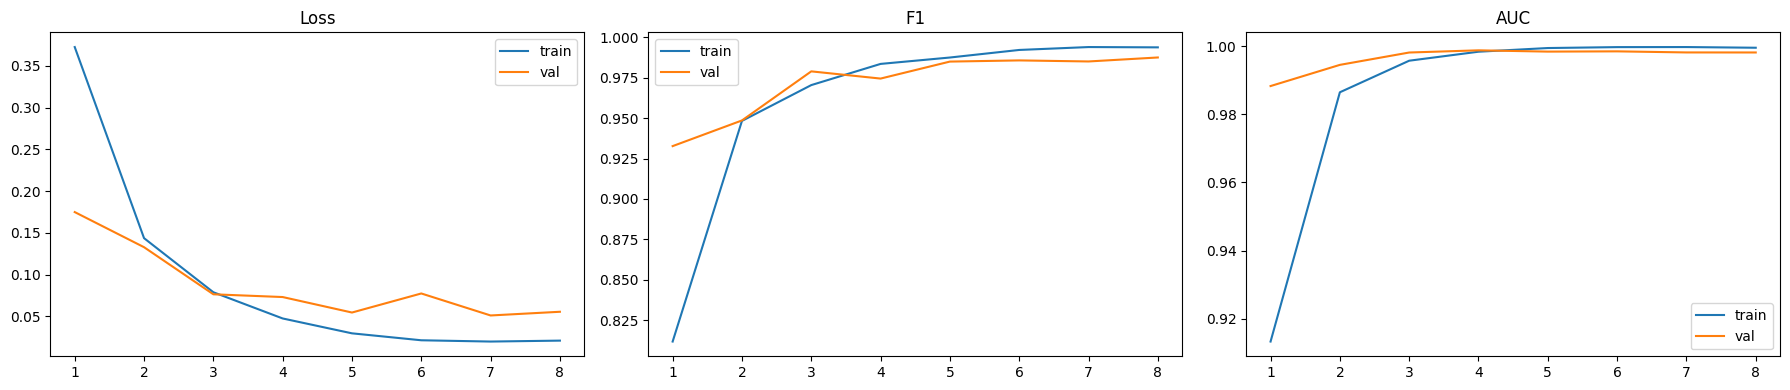

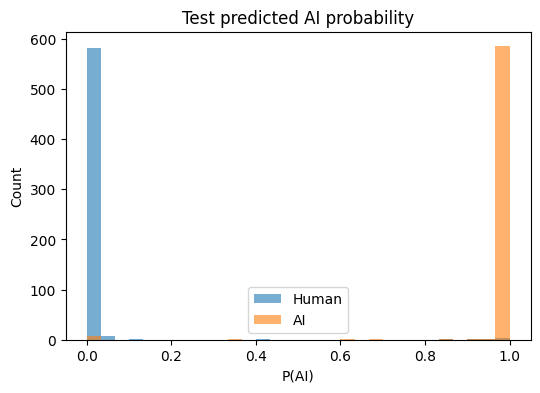

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_f1"], label="train")
axes[1].plot(history_df["epoch"], history_df["val_f1"], label="val")
axes[1].set_title("F1")
axes[1].legend()

axes[2].plot(history_df["epoch"], history_df["train_auc"], label="train")
axes[2].plot(history_df["epoch"], history_df["val_auc"], label="val")
axes[2].set_title("AUC")
axes[2].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.hist(test_probs[test_labels == 0], bins=30, alpha=0.6, label="Human")
plt.hist(test_probs[test_labels == 1], bins=30, alpha=0.6, label="AI")
plt.title("Test predicted AI probability")
plt.xlabel("P(AI)")
plt.ylabel("Count")
plt.legend()
plt.show()


## Result

In [44]:
artifact = {
    "config": CFG,
    "pad_idx": PAD_IDX,
    "unk_idx": UNK_IDX,
    "best_val_f1": best_val_f1
}
with open(os.path.join(CFG["save_dir"], "run_config.json"), "w") as f:
    json.dump(artifact, f, indent=2)

print("Saved outputs to:", CFG["save_dir"])
print("Best checkpoint :", best_path)


Saved outputs to: /content/blstm_cnn_outputs
Best checkpoint : /content/blstm_cnn_outputs/best_blstm_cnn.pt
